Philip Fowler
2025 13 06
A notebook to investigate methods for comparing different datasets

# Load libraries and data

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
import plotly.express as px
from statsmodels.tsa.stattools import adfuller
from pandas.plotting import lag_plot
from scipy.optimize import linear_sum_assignment
from statsmodels.tsa.stattools import grangercausalitytests
import networkx as nx
import h5py


In [41]:
with h5py.File('IFNeuron-stuff/test-1000-ms.hdf5', 'r') as f:
    # List all keys in the file
    print(list(f.keys()))

    # Check the type and shape of each key
    for key in f.keys():
        data_item = f[key]
        print(f"{key}: type={type(data_item)}", end='')
        if hasattr(data_item, 'shape'):
            print(f", shape={data_item.shape}")
        else:
            print()


['trial_0', 'trial_1']
trial_0: type=<class 'h5py._hl.group.Group'>
trial_1: type=<class 'h5py._hl.group.Group'>


In [42]:
with h5py.File('IFNeuron-stuff/test-1000-ms.hdf5', 'r') as f:
    for trial_name in f.keys():
        if trial_name.startswith('trial_'):
            trial_group = f[trial_name]
            print(f"Keys in {trial_name} group:", list(trial_group.keys()))
            for name, item in trial_group.items():
                if isinstance(item, h5py.Dataset):
                    print(f"Dataset '{name}' in {trial_name} shape:", item.shape)
                else:
                    print(f"'{name}' in {trial_name} is a group, not a dataset.")


Keys in trial_0 group: ['data']
Dataset 'data' in trial_0 shape: (1000, 11)
Keys in trial_1 group: ['data']
Dataset 'data' in trial_1 shape: (1000, 11)


In [43]:
with h5py.File('IFNeuron-stuff/test-1000-ms.hdf5', 'r') as f:
    for trial_name in f.keys():
        if trial_name.startswith('trial_'):
            trial_group = f[trial_name]
            for name, item in trial_group.items():
                if isinstance(item, h5py.Dataset):
                    data = item[()]
                    if data.ndim == 2:
                        columns = [f'neuron{i+1}' for i in range(data.shape[1])]
                        df = pd.DataFrame(data, columns=columns)
                    else:
                        df = pd.DataFrame(data)
                    globals()[f"{trial_name.replace('_', '')}_df"] = df

                    new_columns = ['time']
                    for i in range(1, (len(columns))//2 + 1):
                        new_columns.append(f'neuron{i}_spike')
                        new_columns.append(f'neuron{i}_mempot')
                    df.columns = new_columns[:df.shape[1]]

In [44]:
trial0_df.head()

,time,neuron1_spike,neuron1_mempot,neuron2_spike,neuron2_mempot,neuron3_spike,neuron3_mempot,neuron4_spike,neuron4_mempot,neuron5_spike,neuron5_mempot
0,0.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0
1,1.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0
2,2.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0
3,3.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0
4,4.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0


In [45]:
trial1_df.head()

,time,neuron1_spike,neuron1_mempot,neuron2_spike,neuron2_mempot,neuron3_spike,neuron3_mempot,neuron4_spike,neuron4_mempot,neuron5_spike,neuron5_mempot
0,0.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0
1,1.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0
2,2.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0
3,3.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0
4,4.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0


# Exploratory Data Analysis

The first plot here is a raster plot to exampine what a single trial looks like.  

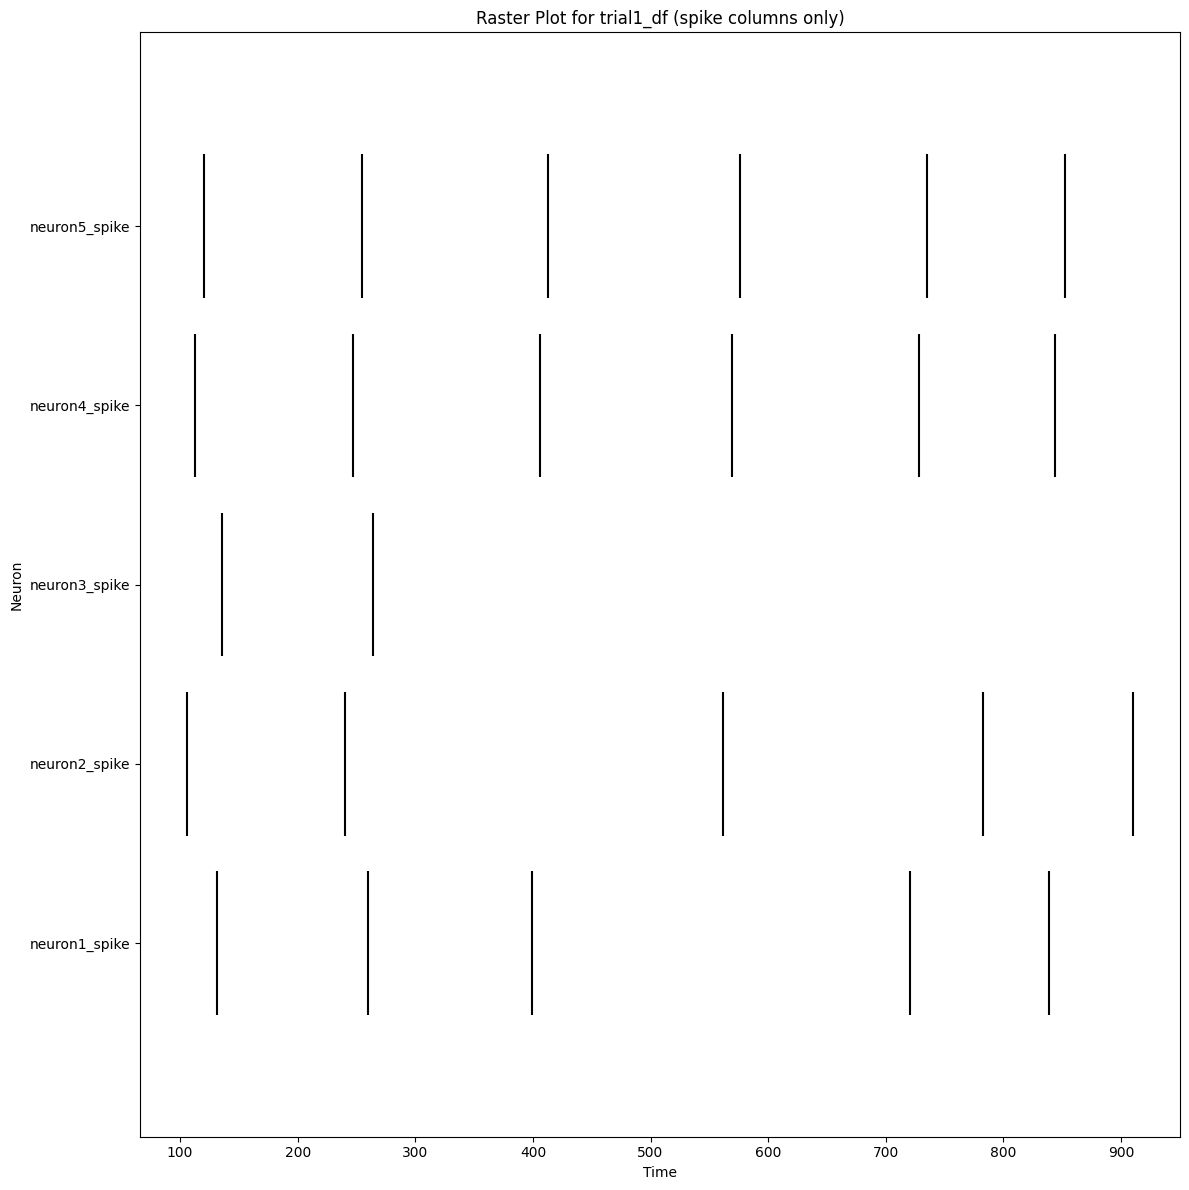

In [46]:
spike_columns = [col for col in trial0_df.columns if col.endswith('_spike')]
spike_times_per_neuron = [trial0_df.index[trial0_df[col] == 1].to_numpy() for col in spike_columns]

plt.figure(figsize=(12, 12))
plt.eventplot(spike_times_per_neuron, orientation='horizontal', colors='black', linelengths=0.8)
plt.yticks(np.arange(len(spike_columns)), spike_columns)
plt.xlabel('Time')
plt.ylabel('Neuron')
plt.title('Raster Plot for trial1_df (spike columns only)')
plt.tight_layout()
plt.show()


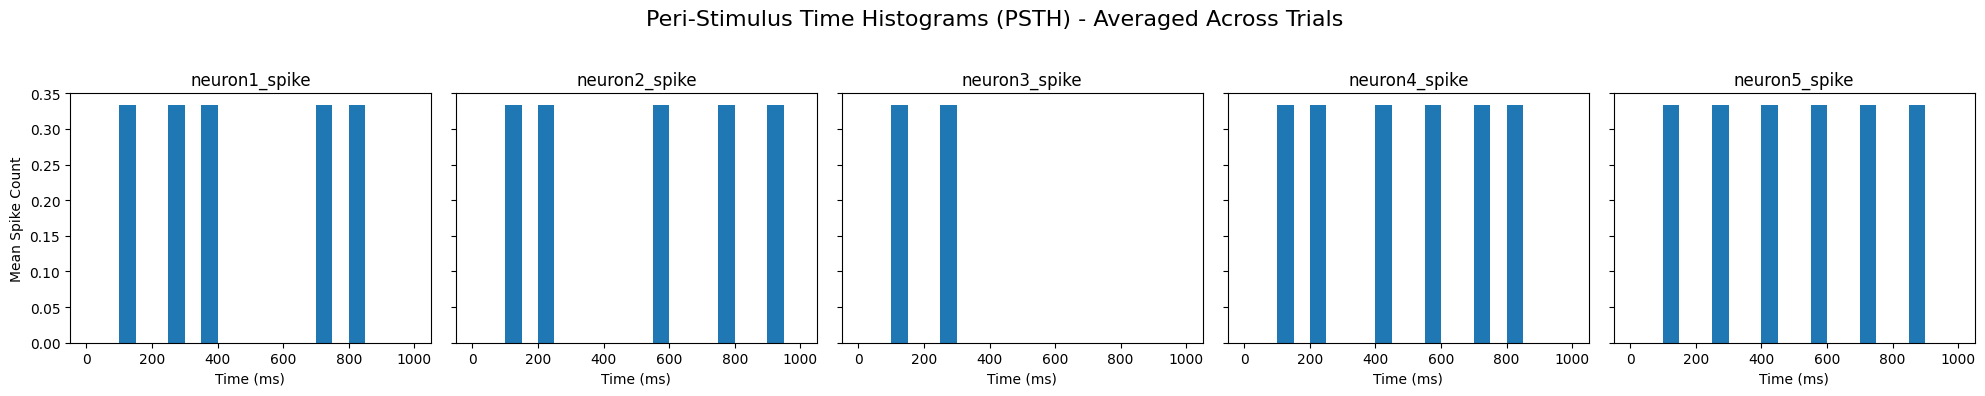

In [47]:
bin_size = 50
num_bins = all_trials[0].shape[0] // bin_size

spike_columns = [col for col in all_trials[0].columns if col.endswith('_spike')]
num_neurons = len(spike_columns)

# Bin spike counts for each neuron in each trial
binned_spikes = np.zeros((len(all_trials), num_bins, num_neurons))
for t, trial_df in enumerate(all_trials):
    for n, col in enumerate(spike_columns):
        spikes = trial_df[col].values[:num_bins*bin_size]
        binned_spikes[t, :, n] = spikes.reshape(num_bins, bin_size).sum(axis=1)

# Average across trials
mean_spike_counts = binned_spikes.mean(axis=0)
time_bins = np.arange(num_bins) * bin_size

fig, axes = plt.subplots(1, num_neurons, figsize=(4*num_neurons, 4), sharey=True)
if num_neurons == 1:
    axes = [axes]
for i, col in enumerate(spike_columns):
    axes[i].bar(time_bins, mean_spike_counts[:, i], width=bin_size, align='edge', color='tab:blue')
    axes[i].set_title(col)
    axes[i].set_xlabel('Time (ms)')
    if i == 0:
        axes[i].set_ylabel('Mean Spike Count')
plt.suptitle('Peri-Stimulus Time Histograms (PSTH) - Averaged Across Trials', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


number of trials: 2


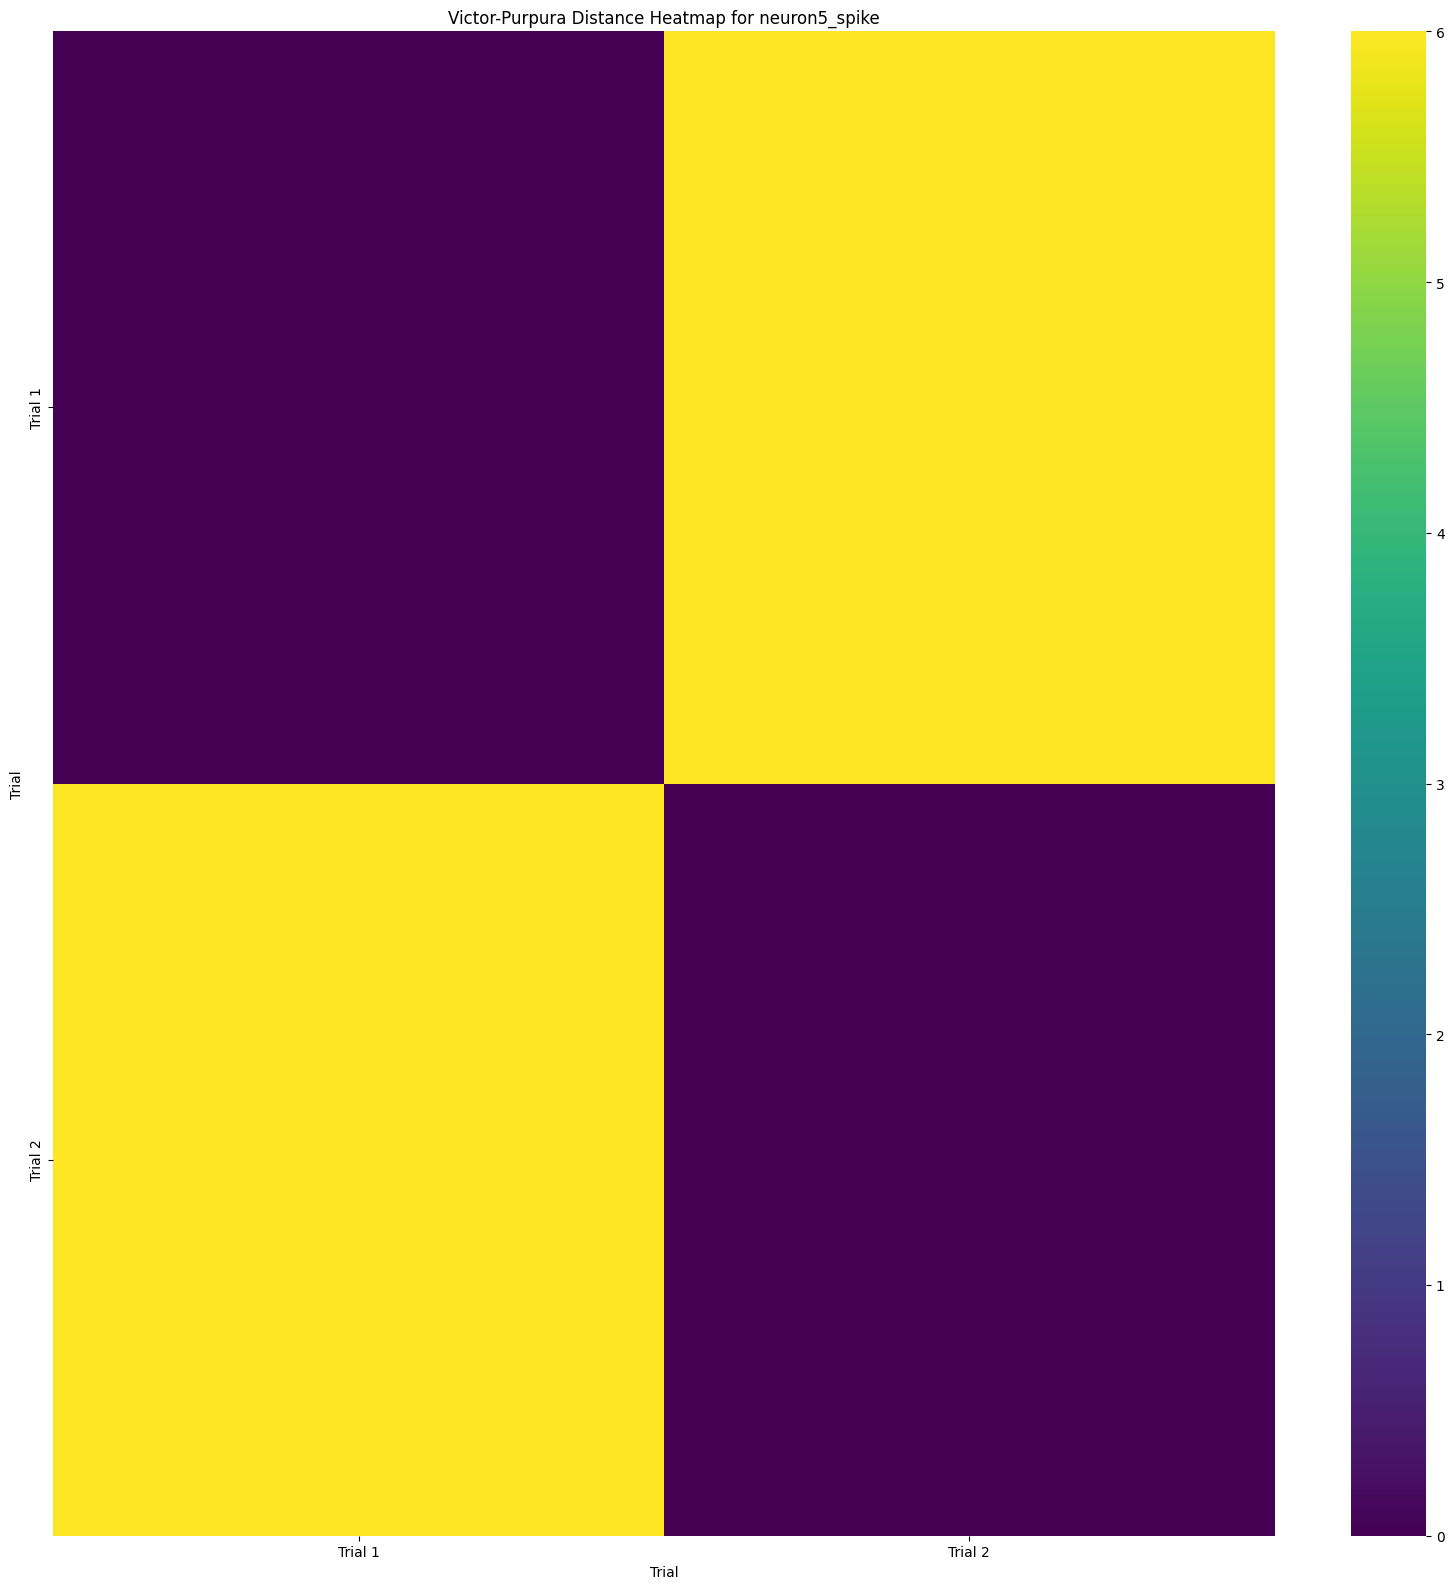

In [53]:
all_trials = [trial0_df, trial1_df]

def victor_purpura_distance(trace1, trace2, q=1.0):
    spike_times1 = np.where(trace1 == 1)[0]
    spike_times2 = np.where(trace2 == 1)[0]
    n = len(spike_times1)
    m = len(spike_times2)
    dp = np.zeros((n+1, m+1))
    dp[:,0] = np.arange(n+1)
    dp[0,:] = np.arange(m+1)
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = q * abs(spike_times1[i-1] - spike_times2[j-1])
            dp[i,j] = min(
                dp[i-1,j] + 1,
                dp[i,j-1] + 1,
                dp[i-1,j-1] + cost
            )
    return dp[n,m]

spike_columns = [col for col in all_trials[0].columns if col.endswith('_spike')]

print(f"number of trials: {len(all_trials)}")

vp_distances = {}
for neuron in spike_columns:
    vp_distances[neuron] = []
    for i in range(len(all_trials)):
        for j in range(i+1, len(all_trials)):
            d = victor_purpura_distance(
                all_trials[i][neuron].values, 
                all_trials[j][neuron].values, 
                q=1.0
            )
            vp_distances[neuron].append({'trial_pair': (i+1, j+1), 'distance': d})

neuron = 'neuron5_spike'
distances = vp_distances[neuron]

trial_numbers = sorted(set([pair['trial_pair'][0] for pair in distances] + [pair['trial_pair'][1] for pair in distances]))
n_trials = max(trial_numbers)

vp_matrix = np.zeros((n_trials, n_trials))
vp_matrix[:] = np.nan

for entry in distances:
    i, j = entry['trial_pair']
    vp_matrix[i-1, j-1] = entry['distance']
    vp_matrix[j-1, i-1] = entry['distance']

np.fill_diagonal(vp_matrix, 0)

plt.figure(figsize=(16, 16))
sns.heatmap(vp_matrix, annot=False, cmap='viridis', xticklabels=[f'Trial {i+1}' for i in range(n_trials)], yticklabels=[f'Trial {i+1}' for i in range(n_trials)])
plt.title(f'Victor-Purpura Distance Heatmap for {neuron}')
plt.xlabel('Trial')
plt.ylabel('Trial')
plt.tight_layout()
plt.show()


# Finding Correlations

So, it seems to me that one of the most important things to find here is correlations between the neurons.  

In our previous examples we had 5 neurons and a diagram of how they were connected.  Here we have 57 neurons, can correlations be found to elucidate which neurons might be connected?

Granger causality is a method that we can use here.  The gist of the idea is that we can use one neuron's time series to predict another.  

Some things to notice.  This heatmap is not symetrical across the diagonal.  This should make sense as neuron1 appears to have some value in predicting neuron18; however, the inverse is not the same.

In [55]:
max_lag = 5

for trial_num in range(1, 2):
    df = globals()[f"trial{trial_num}_df"]
    granger_results = {}
    for source_idx in range(12):
        for target_idx in range(12):
            if source_idx == target_idx:
                continue
            source = f'neuron{source_idx+1}'
            target = f'neuron{target_idx+1}'
            key = (source, target)
            try:
                data = df[[target, source]].astype(float).values
                test_result = grangercausalitytests(data, maxlag=max_lag)
                min_pvalue = min([test_result[lag][0]['ssr_ftest'][1] for lag in range(1, max_lag+1)])
                granger_results[key] = min_pvalue
            except Exception:
                granger_results[key] = np.nan
    globals()[f"granger_results_trial{trial_num}"] = granger_results


In [59]:
num_neurons = 5
neuron_names = [f'neuron{i+1}' for i in range(num_neurons)]
neuron_to_idx = {name: i for i, name in enumerate(neuron_names)}

for trial_num in range(1, 2):
    granger_results = globals()[f"granger_results_trial{trial_num}"]
    p_values_matrix = np.full((num_neurons, num_neurons), np.nan)
    for (source, target), p_value in granger_results.items():
        target_idx = neuron_to_idx[target]
        source_idx = neuron_to_idx[source]
        p_values_matrix[target_idx, source_idx] = p_value
    granger_df = pd.DataFrame(p_values_matrix, index=neuron_names, columns=neuron_names)
    plt.figure(figsize=(12, 10))
    sns.heatmap(granger_df, cmap='viridis_r', annot=False, fmt=".2f",
                linewidths=.5, linecolor='lightgray', cbar_kws={'label': 'P-value'})
    plt.title(f'Granger Causality P-values Between Neuron Pairs (trial{trial_num}_df)', fontsize=16)
    plt.xlabel('Source Neuron', fontsize=12)
    plt.ylabel('Target Neuron', fontsize=12)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


KeyError: 'neuron6'

The following cell creates a graph of thegrange causality results.  Each neuron is a node and the edges are the granger causality results.  

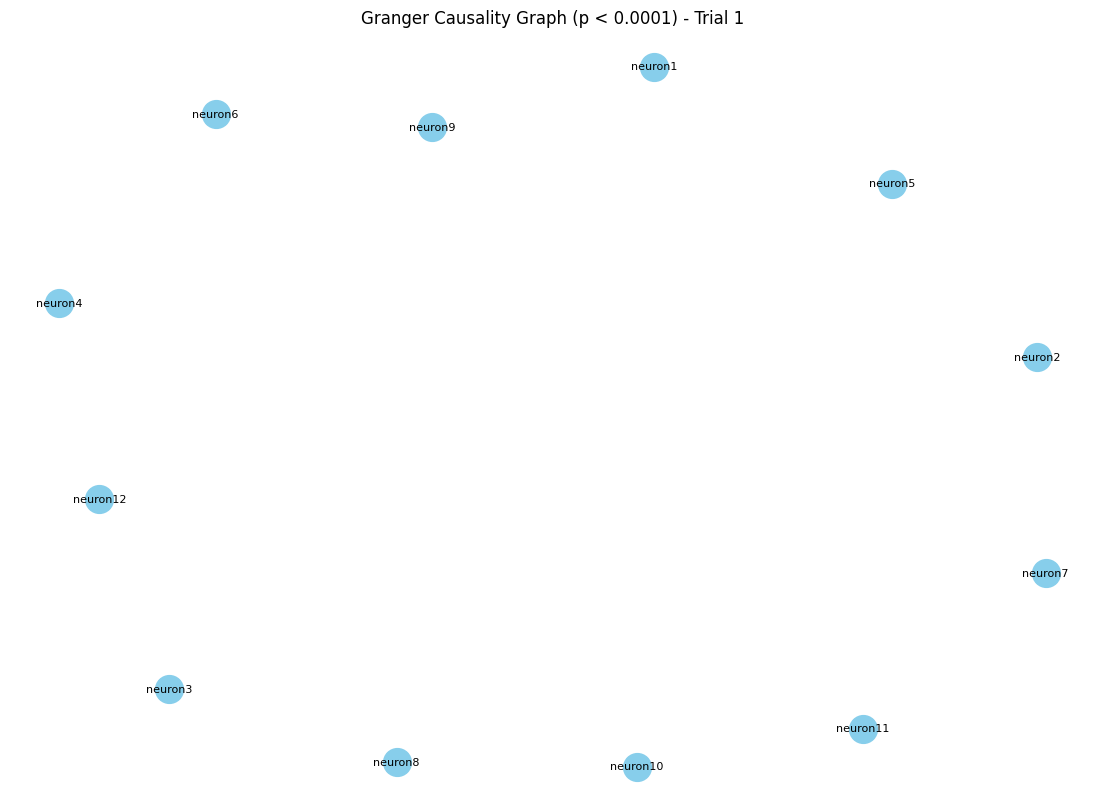

In [57]:
threshold = 0.0001

for trial_num in range(1, 2):
    granger_df = None
    granger_results = globals()[f"granger_results_trial{trial_num}"]
    p_values_matrix = np.full((num_neurons, num_neurons), np.nan)
    for (source, target), p_value in granger_results.items():
        target_idx = neuron_to_idx[target]
        source_idx = neuron_to_idx[source]
        p_values_matrix[target_idx, source_idx] = p_value
    granger_df = pd.DataFrame(p_values_matrix, index=neuron_names, columns=neuron_names)

    G = nx.DiGraph()
    G.add_nodes_from(granger_df.columns)

    for source in granger_df.columns:
        for target in granger_df.index:
            p_value = granger_df.loc[target, source]
            if not np.isnan(p_value) and p_value < threshold:
                G.add_edge(source, target, weight=p_value)

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, seed=42)
    nx.draw_networkx_nodes(G, pos, node_size=400, node_color='skyblue')
    nx.draw_networkx_labels(G, pos, font_size=8)
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=15, edge_color='gray')
    plt.title(f'Granger Causality Graph (p < {threshold}) - Trial {trial_num}')
    plt.axis('off')
    plt.show()

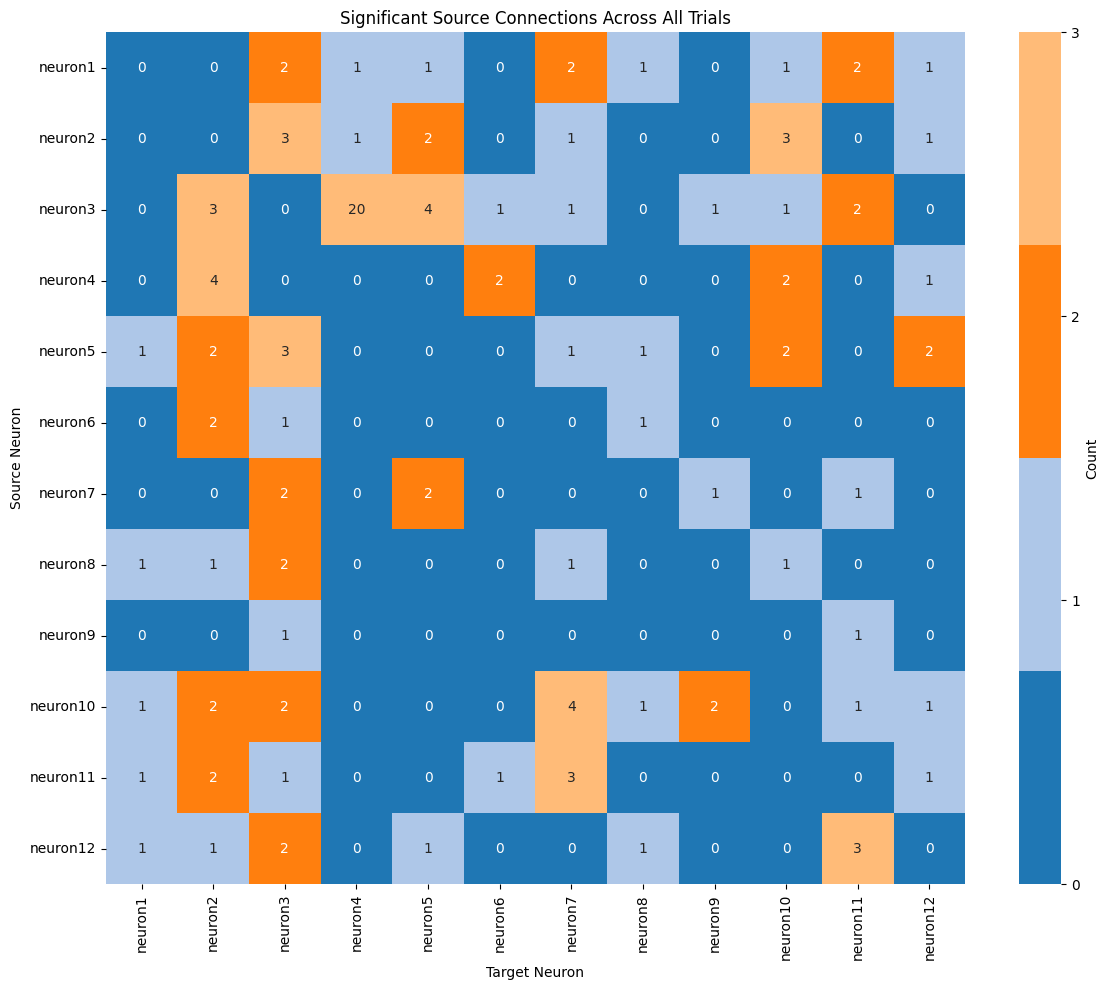

In [23]:
threshold = 0.0001
num_neurons = 12
neuron_names = [f'neuron{i+1}' for i in range(num_neurons)]

connection_counts = np.zeros((num_neurons, num_neurons), dtype=int)

for trial_num in range(1, 58):
    granger_results = globals()[f"granger_results_trial{trial_num}"]
    for (source, target), p_value in granger_results.items():
        if not np.isnan(p_value) and p_value < threshold:
            source_idx = neuron_names.index(source)
            target_idx = neuron_names.index(target)
            connection_counts[source_idx, target_idx] += 1

connection_counts_df = pd.DataFrame(connection_counts, index=neuron_names, columns=neuron_names)


plt.figure(figsize=(12, 10))
cbar_ticks = [0, 1, 2, 3]
sns.heatmap(
    connection_counts_df, 
    annot=True, 
    fmt="d", 
    cmap=sns.color_palette("tab20", 4), 
    cbar_kws={'label': 'Count', 'ticks': cbar_ticks}, 
    vmin=0, vmax=3
)
plt.title('Significant Source Connections Across All Trials')
plt.xlabel('Target Neuron')
plt.ylabel('Source Neuron')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

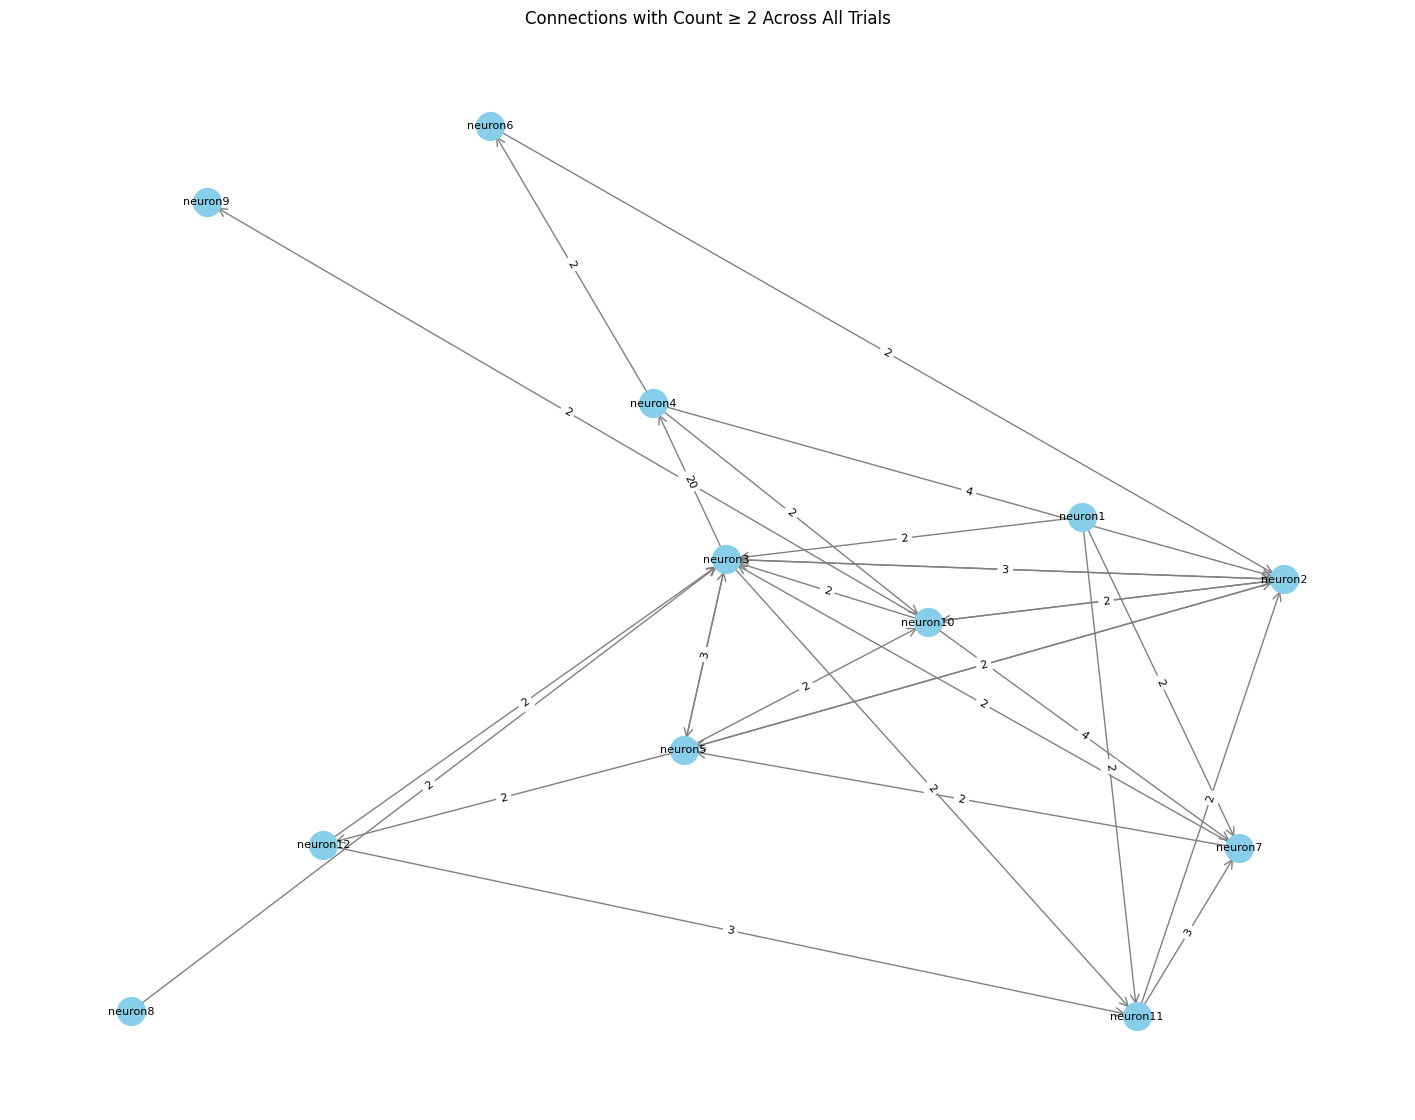

In [24]:
threshold_count = 2

G = nx.DiGraph()
G.add_nodes_from(neuron_names)

for source_idx, source in enumerate(neuron_names):
    for target_idx, target in enumerate(neuron_names):
        count = connection_counts[source_idx, target_idx]
        if count >= threshold_count:
            G.add_edge(source, target, weight=count)

plt.figure(figsize=(18, 14))
pos = nx.spring_layout(G, seed=42, k=1.5) 
nx.draw_networkx_nodes(G, pos, node_size=400, node_color='skyblue')
nx.draw_networkx_labels(G, pos, font_size=8)
edges = nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=15, edge_color='gray')
edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
plt.title('Connections with Count ≥ 2 Across All Trials')
plt.axis('off')
plt.show()